
#🧪 [Assignment 5] Classification with MDC and KNN

In this assignment, we’ll explore the Iris flower dataset (Kaggle):

👉 https://www.kaggle.com/datasets/arshid/iris-flower-dataset

The dataset contains 150 iris samples. Each sample has **four features** — sepal length, sepal width, petal length, and petal width — and a label called species. There are three species, **each with 50 samples**: Iris setosa, Iris versicolor, and Iris virginica.

Your tasks is to:

1.   🟦 Classify flowers using MDC (Minimum Distance Classifier).
2.   🟨 Train a baseline KNN model.
3.   🔍 Compute the error across many values of k.
4.   📈 Plot Error vs. k and select the best k.


## 🗂️ Step 1: Load the Dataset

➡️ Download the csv datafile from Kaggle link above and upload it to your colab.  
➡️ Run the cell below to import pandas and Load the csv file to a dataframe



In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

data=pd.read_csv('IRIS.csv')
data.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
print(f"Number of rows: {len(data)}")

Number of rows: 150


Let's rename the features as:  $$X_1, X_2, X_3, X_4$$ and the label as $$L$$ for simplicity.


In [3]:
#Do not change the code below
data=data.rename(columns={'sepal_length':'X1', 'sepal_width':'X2', 'petal_length':'X3', 'petal_width':'X4',
       'species':'L'})
data.head()

,X1,X2,X3,X4,L
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


##🔄 Step 2: Feature Transformation

⚠️ We have a problem!  

The label is not numeric — it is the name of the species 🌸.  
Use the following code to 🔢 convert the labels into numbers:

In [5]:
# Let's first import the preprocessing module
from sklearn import preprocessing

# Create a LabelEncoder model
le = preprocessing.LabelEncoder()

# Fit the encoder on the label column
le.fit(data['L'])
# The model will find the unique class labels (number of classes present)

# Print the labels found in the column
list(le.classes_)

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

In [6]:
#Following line will convert the labels to an array of numbers
le.transform(data['L'])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
#Lets replace these numbers with the labels in data
data['L']=le.transform(data['L'])

In [8]:
data.head()

,X1,X2,X3,X4,L
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 📊 Step 3: Visualization

Now that all columns are numerical, and before starting the classification, we will create a visualization to get a sense of the data trends.

### 3.1. Histogram of Labels (Class Distribution)

We plot the label distribution to check **if the dataset is balanced** across classes. If one class has far fewer samples than the others, the model may become biased and perform poorly on that minority class. From this plot, we can learn whether each class has roughly the same number of samples (**a balanced dataset**) or if there is a class imbalance that we should pay attention to.


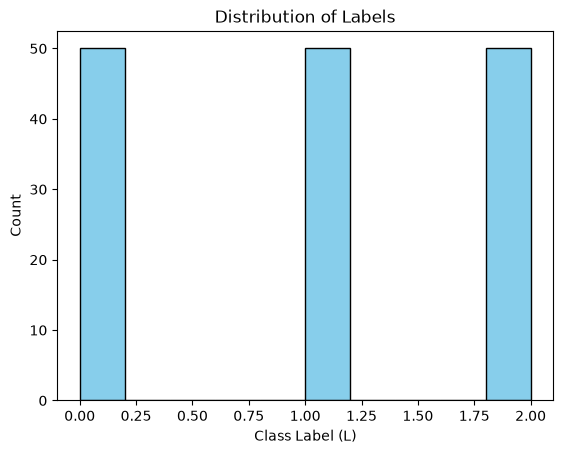

In [9]:
import matplotlib.pyplot as plt

plt.hist(data['L'], color='skyblue', edgecolor='black')
plt.xlabel("Class Label (L)")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()

### 3.2. Pairplot of Features (Scatter Matrix with Histograms)

We use the pairplot to explore the relationships between features and to see how the classes are separated in feature space.

The diagonal plots show histograms of each individual feature, which let us examine how that feature is distributed within and across classes. For example, **we can quickly see whether certain features have different ranges or centers for each class**.

The off-diagonal scatter plots, on the other hand, show how pairs of features relate to each other. **These plots reveal whether classes form clear clusters in two dimensions, whether some features are strongly correlated**, and where overlapping regions exist that may make classification more challenging.


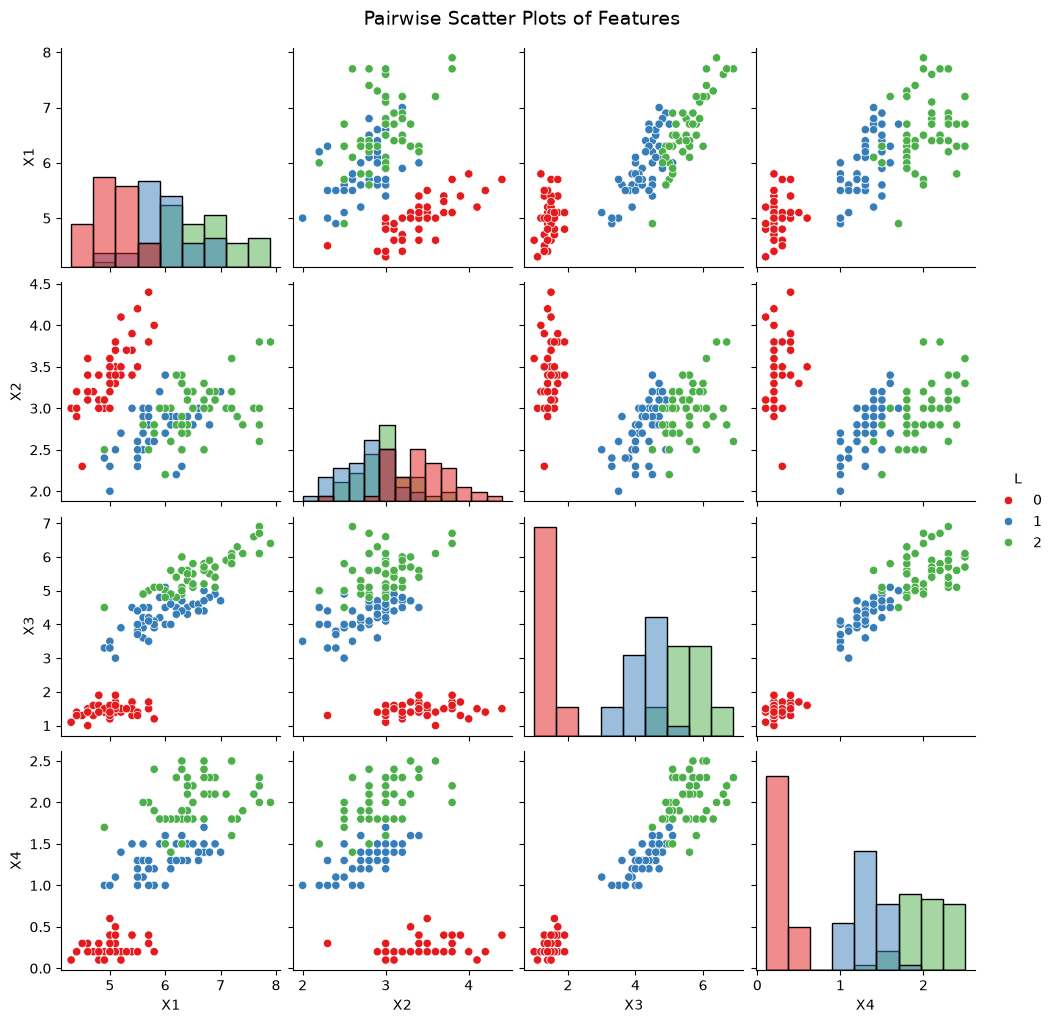

In [10]:
import seaborn as sns

sns.pairplot(data, vars=['X1','X2','X3','X4'],
             hue='L', palette='Set1', diag_kind='hist')
plt.suptitle("Pairwise Scatter Plots of Features", y=1.02, fontsize=14)
plt.show()

Pay close attention to the histogram of Feature X_4 (bottom right). You’ll notice that the increase in this feature alone separates the red class (Class 0) from the others. When $X_4< 1$, the histogram bars are almost entirely red, meaning they belong to one of the classes. Once $X_4 > 1$, the other classes begin to appear. This shows that by looking at X_4 alone, we can already distinguish one species from the rest.



## ✂️ Step 4: Split Train/Test

Import `train_test_split` from Scikit-learn and split the Features(X) and Label(Y) to **60%** training subset and **40%** test subset.

Make sure that you name the 4 variables as `X_train`, `X_test`, `Y_train`, `Y_test`

<font color=blue>Add the parameter `random_state=37` to your `train_test_split` so that your results are the same as other students’. We’ll talk more about this later, but in short: setting the random state ensures that no matter which computer or runtime you use, everyone gets the same training and testing distribution.


In [21]:
### BEGIN SOLUTION
from sklearn.model_selection import train_test_split

# As in previous assignments, pick test_Size=0.4 vs train_size=0.6 to maximimze gradescope score.
X_train, X_test, Y_train, Y_test = train_test_split(data[['X1','X2','X3','X4']], data['L'], test_size=0.4, random_state=37)
Y_train.head()
X_test.head()




### END SOLUTION

,X1,X2,X3,X4
74,6.4,2.9,4.3,1.3
27,5.2,3.5,1.5,0.2
104,6.5,3.0,5.8,2.2
142,5.8,2.7,5.1,1.9
6,4.6,3.4,1.4,0.3


Run the following code block to visualize the training and testing subsets, and make sure the variables are defined correctly.

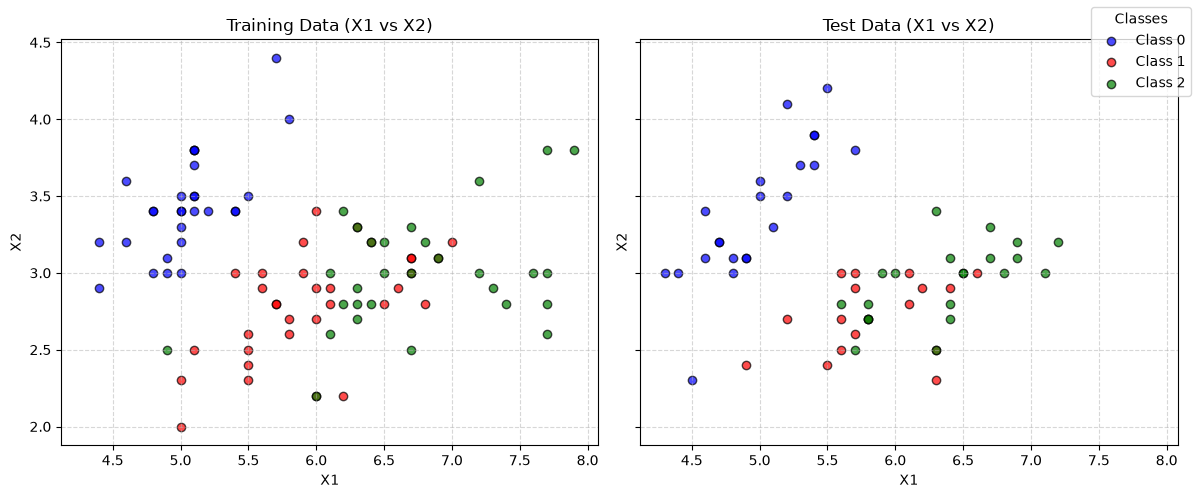

In [22]:
import matplotlib.pyplot as plt

# Define colors for classes
colors = ['blue', 'red', 'green']
labels = ['Class 0', 'Class 1', 'Class 2']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Training data
for i, (color, label) in enumerate(zip(colors, labels)):
    subset = X_train[Y_train == i]
    axes[0].scatter(subset['X1'], subset['X2'], color=color, label=label, alpha=0.7, edgecolor='k')
axes[0].set_title("Training Data (X1 vs X2)")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Test data
for i, (color, label) in enumerate(zip(colors, labels)):
    subset = X_test[Y_test == i]
    axes[1].scatter(subset['X1'], subset['X2'], color=color, label=label, alpha=0.7, edgecolor='k')
axes[1].set_title("Test Data (X1 vs X2)")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].grid(True, linestyle="--", alpha=0.5)

# Add a single legend for both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", title="Classes")

plt.tight_layout()
plt.show()

## 🎯 Step 5: Mean Distance Classifier (NearestCentroid)

Complete the following code and train a model variable named `MDC_Model` using the training data with the Mean Distance Classifier.

In [24]:
### BEGIN SOLUTION
from sklearn.neighbors import NearestCentroid
MDC_Model=NearestCentroid()
MDC_Model.fit(X_train, Y_train)


### END SOLUTION

,"metric metric: {""euclidean"", ""manhattan""}, default=""euclidean""Metric to use for distance computation.If `metric=""euclidean""`, the centroid for the samples corresponding to eachclass is the arithmetic mean, which minimizes the sum of squared L1 distances.If `metric=""manhattan""`, the centroid is the feature-wise median, whichminimizes the sum of L1 distances... versionchanged:: 1.5 All metrics but `""euclidean""` and `""manhattan""` were deprecated and now raise an error... versionchanged:: 0.19 `metric='precomputed'` was deprecated and now raises an error",'euclidean'
,"shrink_threshold shrink_threshold: float, default=NoneThreshold for shrinking centroids to remove features.",None
,"priors priors: {""uniform"", ""empirical""} or array-like of shape (n_classes,), default=""uniform""The class prior probabilities. By default, the class proportions areinferred from the training data... versionadded:: 1.6",'uniform'
Name,Type,Value
"centroids_ centroids_: array-like of shape (n_classes, n_features)Centroid of each class.","ndarray[float64](3, 4)","[[5.03,3.44,1.47,0.26], [5.98,2.79,4.31,1.36], [6.75,2.99,5.67,2.01]]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)The class prior probabilities... versionadded:: 1.6","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: array of shape (n_classes,)The unique classes labels.","ndarray[int64](3,)","[0,1,2]"
"deviations_ deviations_: ndarray of shape (n_classes, n_features)Deviations (or shrinkages) of the centroids of each class from theoverall centroid. Equal to eq. (18.4) if `shrink_threshold=None`,else (18.5) p. 653 of [2]. Can be used to identify features usedfor classification... versionadded:: 1.6","ndarray[float64](3, 4)","[[ -5.97, 3.14,-16.96, -9.62], [ 0.38, -2.48, 3.55, 1.49], [ 5.53, -0.55, 13.13, 7.99]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['X1','X2','X3','X4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"within_class_std_dev_ within_class_std_dev_: ndarray of shape (n_features,)Pooled or within-class standard deviation of input data... versionadded:: 1.6","ndarray[float64](4,)","[0.55,0.35,0.48,0.23]"


Complete the following code block and use the trained model to predict the species type (label). Name the predictions on the training data `MDC_Predicted_train` and the predictions on the testing data `MDC_Predicted_test`.

In [26]:
### BEGIN SOLUTION

MDC_Predicted_train=MDC_Model.predict(X_train)
MDC_Predicted_test=MDC_Model.predict(X_test)

### END SOLUTION

array([0, 2, 2, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 1, 1, 2, 2, 0, 2, 2, 1, 0,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 2, 1, 2, 1, 0, 1, 0, 2, 2,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 2, 1, 1, 0, 0, 2, 0, 1, 0, 2, 2, 0, 1, 1, 1, 1, 0, 2, 0, 1,
       2, 2])

Complete the following code block and count the misclassified points. Store the number of misclassified flowers in the training set in a variable named `MDC_Misclassified_train`, and the number of misclassified flowers in the testing set in a variable named `MDC_Misclassified_test`.



In [27]:
### BEGIN SOLUTION
import numpy as np
MDC_Misclassified_train=np.count_nonzero(MDC_Predicted_train!=Y_train)
MDC_Misclassified_test=np.count_nonzero(MDC_Predicted_test!=Y_test)



### END SOLUTION
print("Number of misclassified flowers in the training set:", MDC_Misclassified_train)
print("Number of misclassified flowers in the testing set:", MDC_Misclassified_test)

Number of misclassified flowers in the training set: 8
Number of misclassified flowers in the testing set: 6



## 🤝 Step 6: Implementing the K-Nearest Neighbors (KNN) Model

Complete the following code block to implement KNN for K = 2, 3, 4, 5, 6.

For each value of K, count the number of misclassified points in both the training and testing subsets. Store the results in two lists: `KNN_Misclassified_train` and `KNN_Misclassified_test`.

Each list should contain exactly 5 numbers, corresponding to the misclassification counts for the 5 different values of K.


In [52]:
### BEGIN SOLUTION
from sklearn.neighbors import KNeighborsClassifier

KNN_Misclassified_train = []
KNN_Misclassified_test  = []

for k in range(2,7):
    KNN_Model=KNeighborsClassifier(n_neighbors=k)
    KNN_Model.fit(X_train, Y_train)
    KNN_Predicted_train=KNN_Model.predict(X_train)
    KNN_Predicted_test=KNN_Model.predict(X_test)
    KNN_Misclassified_train.append(np.count_nonzero(KNN_Predicted_train!=Y_train))
    KNN_Misclassified_test.append(np.count_nonzero(KNN_Predicted_test!=Y_test))

### END SOLUTION

In [53]:
#If the code above works correctly, the following comamands should print True
print(len(KNN_Misclassified_train)==5)
print(len(KNN_Misclassified_test)==5)

True
True


Analyze the results you computed above and choose the best K for K-Nearest Neighbors based on performance on both the training and testing subsets. Then complete the following code block to train KNN with your chosen K. Name the model `KNN_Best`.

In [54]:
### BEGIN SOLUTION
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
# Search the count of misclassified test, choose that one.
k_min_idx = np.argmin(KNN_Misclassified_test)
print(f"Num neighbors with minimum misclassification: {k_min_idx+2}")
KNN_Best=KNeighborsClassifier(n_neighbors=k_min_idx+2)
KNN_Best.fit(X_train, Y_train)


### END SOLUTION

Num neighbors with minimum misclassification: 5


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(5)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [57]:
### BEGIN SOLUTION


KNN_Predicted_train=KNN_Best.predict(X_train)
KNN_Predicted_test=KNN_Best.predict(X_test)
### END SOLUTION

Complete the following code block and count the misclassified points. Store the number of misclassified flowers in the training set in a variable named `KNN_Best_Misclassified_train`, and the number of misclassified flowers in the testing set in a variable named `KNN_Best_Misclassified_test`.



In [58]:
### BEGIN SOLUTION
import numpy as np


KNN_Best_Misclassified_train=np.count_nonzero(KNN_Predicted_train!=Y_train)
KNN_Best_Misclassified_test=np.count_nonzero(KNN_Predicted_test!=Y_test)


### END SOLUTION
print("Number of misclassified flowers in the training set utilizing KNN:",KNN_Best_Misclassified_train)
print("Number of misclassified flowers in the testing set utilizing KNN:", KNN_Best_Misclassified_test)

Number of misclassified flowers in the training set utilizing KNN: 2
Number of misclassified flowers in the testing set utilizing KNN: 2



## 🎯 Wrap-Up (Reflect)

🟦 Minimum Distance Classifier (MDC)

The Minimum Distance Classifier is a simple and efficient method that assigns each data point to the class whose centroid is closest in the feature space. It is fast, easy to interpret, and requires very little storage once the centroids are calculated. However, MDC assumes that classes are **linearly separable** and form compact, roughly spherical clusters. Because of this assumption, it struggles with nonlinear decision boundaries and can be strongly affected by outliers, which may shift centroids and cause misclassification. The thresholds it creates in n-dimensional space are clear and linear (straight lines in 2D, hyperplanes in higher dimensions), which makes the model interpretable but not flexible.
	•	Useful: when data forms clear, compact clusters; when you need a fast baseline model; when working with well-structured, high-dimensional data.
	•	Not useful: when classes overlap or have nonlinear relationships; when the dataset contains many outliers.

🟨 K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a flexible, non-parametric method that classifies a point based on the majority label of its nearest neighbors. Unlike MDC, **it does not assume linear separability** and can capture complex, nonlinear decision boundaries that adapt to the local structure of the data. This makes KNN powerful for irregular class shapes. However, KNN requires storing the entire training set, making predictions slower as the dataset grows. It is also sensitive to irrelevant features and requires feature scaling so that distance metrics are meaningful. The choice of K plays a crucial role: small values may lead to overfitting, while large values may oversmooth the decision boundary. In n-dimensional space, KNN thresholds bend and adapt to the data, giving it more flexibility than MDC but at the cost of efficiency.
	•	Useful: when class boundaries are nonlinear or irregular; with moderately sized datasets; when sufficient memory is available for storing the training data.
	•	Not useful: for very large datasets (due to slow prediction); in very high-dimensional spaces (curse of dimensionality); when irrelevant or unscaled features dominate the distance metric.
